In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [3]:
df = pd.read_parquet("/home/gq11/Documents/Code/Jupiter Notebook/df_clean.parquet")

In [4]:
df.describe()

,appID,release_date,peak_ccu,required_age,price,dlc_count,metacritic_score,positive,negative,achievements,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks
count,1.241460e+05,124146,1.241460e+05,124146.000000,124146.000000,124146.000000,124146.000000,1.241460e+05,1.241460e+05,124146.000000,1.241460e+05,124146.000000,1.241460e+05,124146.000000
mean,2.007202e+06,2022-02-08 08:36:58.007829,5.391834e+01,0.166151,4.786144,0.540573,2.533855,1.032103e+03,1.671155e+02,18.010520,2.054626e+02,13.628204,1.714364e+02,14.550578
min,1.000000e+01,1997-06-30 00:00:00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,1.072032e+06,2020-01-16 00:00:00,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
50%,1.926950e+06,2022-12-06 00:00:00,0.000000e+00,0.000000,2.390000,0.000000,0.000000,5.000000e+00,1.000000e+00,2.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
75%,2.901968e+06,2024-10-24 00:00:00,0.000000e+00,0.000000,5.390000,0.000000,0.000000,3.600000e+01,1.000000e+01,19.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
max,4.326570e+06,2026-09-08 00:00:00,1.013936e+06,21.000000,999.980000,3703.000000,97.000000,7.642084e+06,1.173003e+06,9821.000000,3.429544e+06,20088.000000,3.429544e+06,20088.000000
std,1.100848e+06,NaN,3.706328e+03,1.646332,12.507614,14.426264,13.580489,2.791776e+04,5.341348e+03,140.633042,1.114814e+04,268.710314,1.113308e+04,292.692992


Prices distribution

In [29]:
df['price_category'] = np.where(df['price'] > 0, 'Paid', 'Free')
df[['price', 'price_category']]


,price,price_category
0,0.00,Free
1,5.24,Paid
2,4.99,Paid
3,8.99,Paid
4,4.99,Paid
...,...,...
124141,6.99,Paid
124142,3.99,Paid
124143,3.59,Paid
124144,2.99,Paid


In [6]:
df2 = df.copy()

In [7]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 124146 entries, 0 to 124145
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   appID                     124146 non-null  int64         
 1   name                      124146 non-null  str           
 2   release_date              124146 non-null  datetime64[us]
 3   estimated_owners          124146 non-null  str           
 4   peak_ccu                  124146 non-null  int64         
 5   required_age              124146 non-null  int16         
 6   price                     124146 non-null  float64       
 7   dlc_count                 124146 non-null  int16         
 8   supported_languages       124146 non-null  object        
 9   full_audio_languages      124146 non-null  object        
 10  windows                   124146 non-null  bool          
 11  mac                       124146 non-null  bool          
 12  linux        

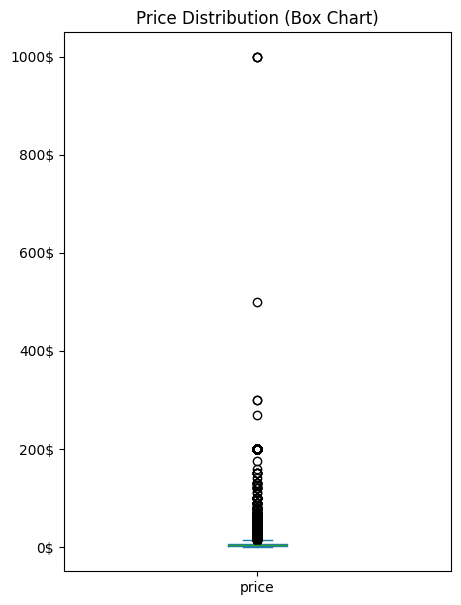

In [8]:
fig, ax = plt.subplots(figsize=(5,7))
df2[df2['price_category'] == 'Paid']['price'].plot(kind='box')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1:.0f}$'))
ax.set_title('Price Distribution (Box Chart)')
plt.show()

Free-to-Play vs Paid

In [7]:
df['mean_estimated_owners'] = df['estimated_owners'].str.split(' - ', expand=True).astype(float).mean(axis=1)

In [96]:
df2 = df.copy()

In [24]:
df2['price_category'].value_counts()

price_category
Paid    97734
Free    26412
Name: count, dtype: int64

number of game

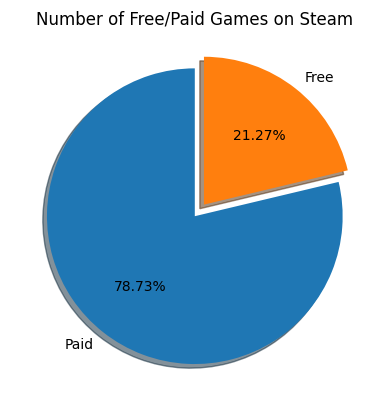

In [97]:
fig, ax = plt.subplots()
explode = (0, 0.1)
df2['price_category'].value_counts().plot(kind='pie', startangle=90, autopct='%1.2f%%', shadow=True, explode=explode)
ax.set_title('Number of Free/Paid Games on Steam')

plt.show()

average download

(array([0, 1]), [Text(0, 0, 'Free'), Text(1, 0, 'Paid')])

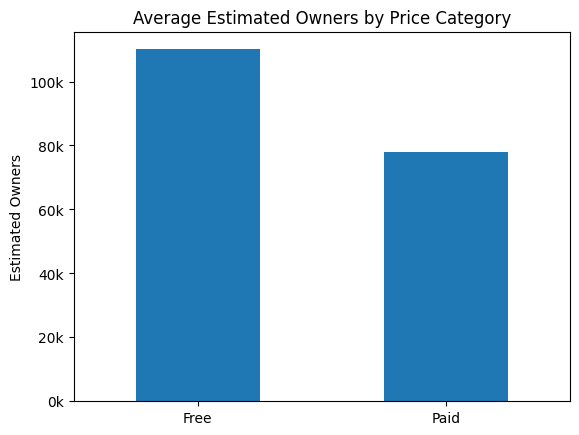

In [42]:
fig, ax = plt.subplots()
df2.groupby('price_category')['mean_estimated_owners'].mean().plot(kind='bar')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k'))
ax.set_ylabel("Estimated Owners")
ax.set_xlabel("")
ax.set_title("Average Estimated Owners by Price Category")

plt.xticks(rotation = 0)


most owned paid game

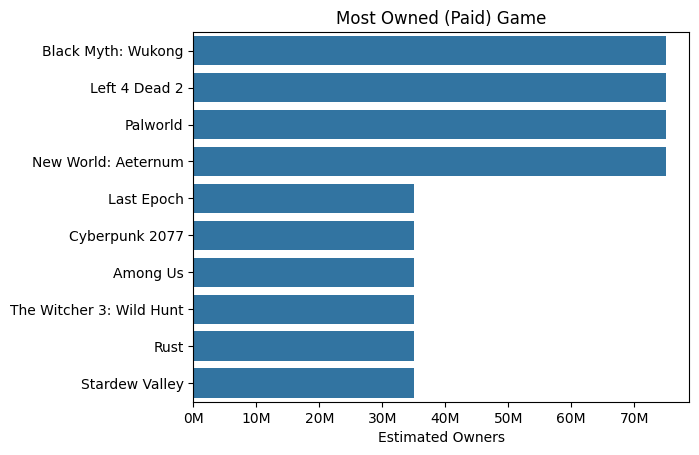

In [ ]:
plot1 = df2[df2['price_category'] == 'Paid'][['name', 'mean_estimated_owners']].sort_values('mean_estimated_owners', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='mean_estimated_owners', y='name')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_xlabel("Estimated Owners")
ax.set_ylabel("")
ax.set_title("Most Owned (Paid) Game")
plt.show()

How are games priced across different tags?

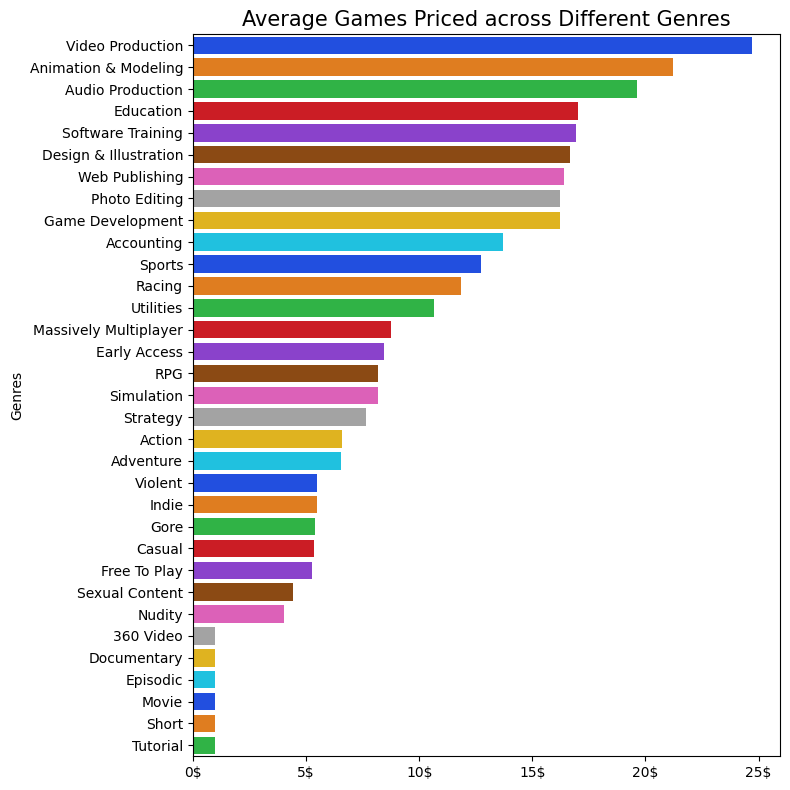

In [31]:
df2 = df.copy()
df2 = df2[df2['price_category'] == 'Paid']
df2 = df2[['genres', 'price']].explode('genres')

fig, ax = plt.subplots(figsize=(8, 8))
plot1 = df2.groupby('genres')['price'].mean().sort_values(ascending=False)
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="bright")
ax.set_xlabel('')
ax.set_ylabel('Genres')
ax.set_title('Average Games Priced across Different Genres', fontsize=15)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}$'))
fig.tight_layout()

Ratings

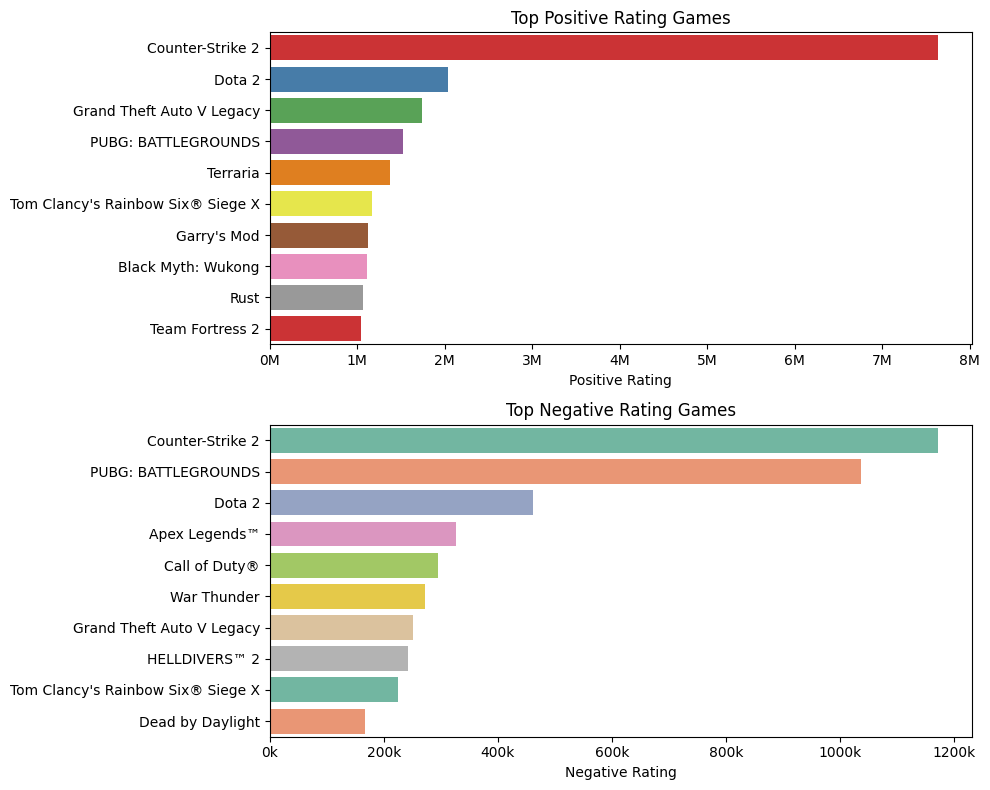

In [33]:
df2 = df.copy()
df2 = df2[(df2['positive'] > 0) | (df2['negative'] > 0)]

plot1 = df2[['name', 'positive']].sort_values('positive', ascending=False).head(10)
plot2 = df2[['name', 'negative']].sort_values('negative', ascending=False).head(10)

fig, ax = plt.subplots(2,1, figsize=(10,8))

sns.barplot(data=plot1, x='positive', y='name', hue='name', palette="Set1", ax=ax[0])
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax[0].set_xlabel("Positive Rating")
ax[0].set_ylabel("")
ax[0].set_title("Top Positive Rating Games")

sns.barplot(data=plot2, x='negative', y='name', hue='name', palette="Set2", ax=ax[1])
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k'))
ax[1].set_xlabel("Negative Rating")
ax[1].set_ylabel("")
ax[1].set_title("Top Negative Rating Games")

fig.tight_layout()
plt.show()

Developers

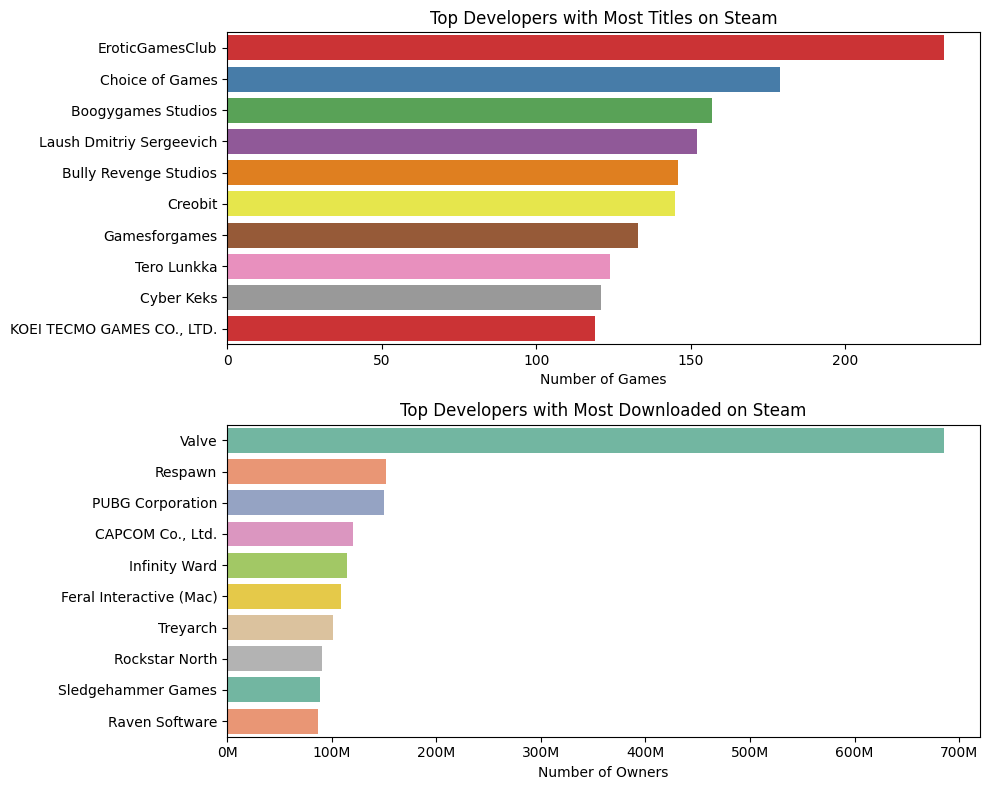

In [22]:
df2 = df.copy()
df2 = df2.explode('developers')

plot1 = df2['developers'].value_counts().head(10)
plot2 = df2.groupby('developers')['mean_estimated_owners'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(2,1, figsize=(10,8))

sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set1", ax=ax[0])
ax[0].set_xlabel('Number of Games')
ax[0].set_ylabel('')
ax[0].set_title('Top Developers with Most Titles on Steam')

sns.barplot(x=plot2.values, y=plot2.index, hue=plot2.index, palette="Set2", ax=ax[1])
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax[1].set_xlabel('Number of Owners')
ax[1].set_ylabel('')
ax[1].set_title('Top Developers with Most Downloaded on Steam')

fig.tight_layout()
plt.show()

Publishers

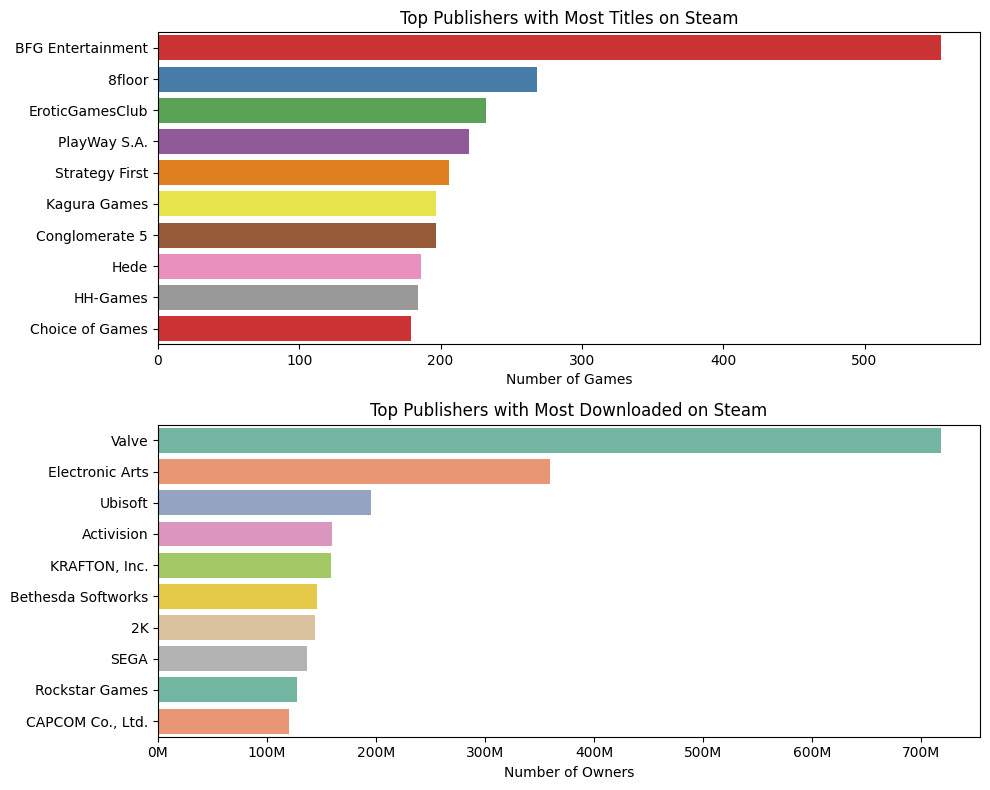

In [23]:
df2 = df.copy()
df2 = df2.explode('publishers')

plot1 = df2['publishers'].value_counts().head(10)
plot2 = df2.groupby('publishers')['mean_estimated_owners'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(2,1, figsize=(10,8))

sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set1", ax=ax[0])
ax[0].set_xlabel('Number of Games')
ax[0].set_ylabel('')
ax[0].set_title('Top Publishers with Most Titles on Steam')

sns.barplot(x=plot2.values, y=plot2.index, hue=plot2.index, palette="Set2", ax=ax[1])
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax[1].set_xlabel('Number of Owners')
ax[1].set_ylabel('')
ax[1].set_title('Top Publishers with Most Downloaded on Steam')

fig.tight_layout()
plt.show()

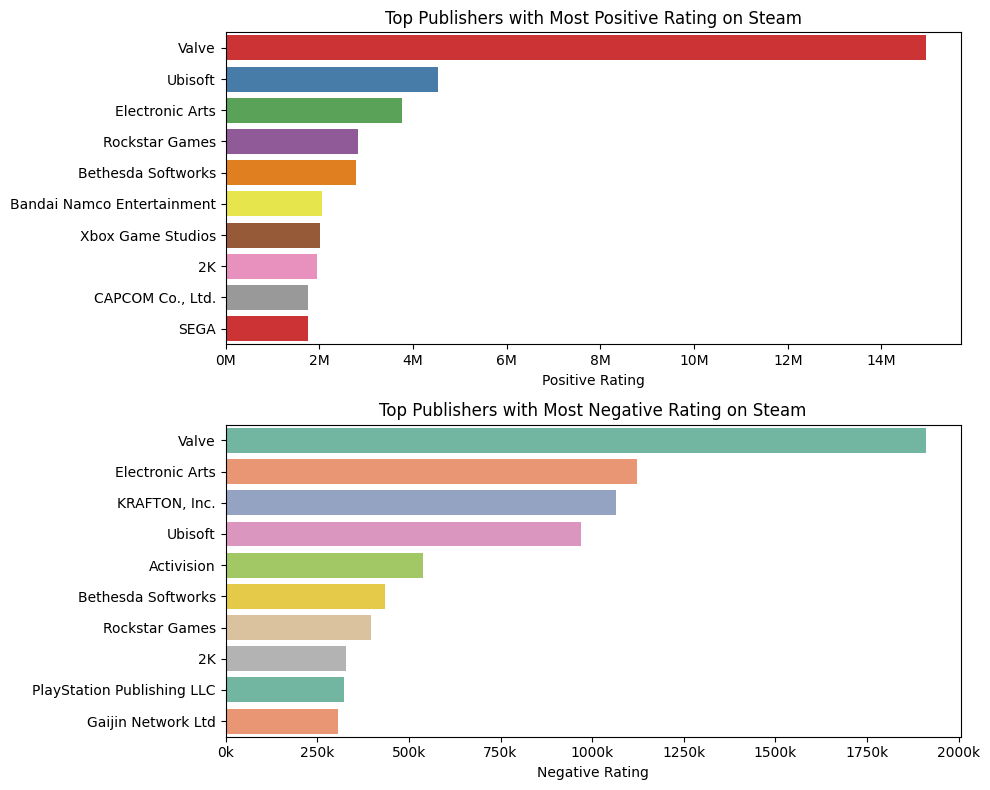

In [50]:
df2 = df.copy()
df2 = df2.explode('publishers')

plot1 = df2.groupby('publishers')['positive'].sum().reset_index().sort_values(by='positive', ascending=False).head(10)
plot2 = df2.groupby('publishers')['negative'].sum().reset_index().sort_values(by='negative', ascending=False).head(10)

fig, ax = plt.subplots(2,1, figsize=(10,8))

sns.barplot(data=plot1, x='positive', y='publishers', hue='publishers', palette="Set1", ax=ax[0])
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax[0].set_xlabel("Positive Rating")
ax[0].set_ylabel("")
ax[0].set_title("Top Publishers with Most Positive Rating on Steam")

sns.barplot(data=plot2, x='negative', y='publishers', hue='publishers', palette="Set2", ax=ax[1])
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k'))
ax[1].set_xlabel("Negative Rating")
ax[1].set_ylabel("")
ax[1].set_title("Top Publishers with Most Negative Rating on Steam")

fig.tight_layout()
plt.show()